# Applied Data Science - Exercise 1

This exercise is one of five assignments in the course T-786-APDS Applied Data Science at Reykjavik University.

## Preparation

Please free to check chapters 2 of the textbook ´Hands-on Machine Learning with SciKit-Learn, Keras and TensorFlow' for the lab.


## Task

<img src="https://images.unsplash.com/photo-1606922699403-9a40186fcb9b?ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&ixlib=rb-1.2.1&auto=format&fit=crop&w=1267&q=80" alt="second hand car" style="width: 400px;"/>

You are a data scientist at a large online marketplate in the US. The platform has millions of users and hundreds of categories of items for sale and operates in a highly competitive industry. Management has decided to expand the marketplace to include sales of second hand cars. To avoid potential issues, management wants to automatically predict an asking price for a given car. You have been tasked with creating a model which predicts a reasonable price for a car, given the information available about the car on the platform.

For example, what would be a reasonable asking price for a 2015 Toyota Corolla in good condition, for sale in Alberta?

If your model works well, it will be used to give sellers a price idea for a new listing (and maybe warn the seller that they may have made a typo in the price). The output of your model may also be used as input into another model which detects fraudulent sales listings and scams. The only viable alternative is to manually check the prices for all new listings, so your model could potentially result in substantial savings for the company.

Optimally, you would use data from users of your own platform. However, since this is the first time you are selling second hand cars, you cannot use your own data. After some research, you decide to train your model on [data scraped from the Craigslist website](https://www.kaggle.com/austinreese/craigslist-carstrucks-data). This data can be found in the file `vehicles.csv`.

In this first exercise, our focus is on the preprocessing of data. We start by exploring the dataset to gain insights.

To complete the exercise, please run the cells in this notebook, filling in the missing code where needed. The notebook mostly follows the steps in chapter 2 of the textbook.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

The code in this exercise has been tested for python version 3.10and probably works for any version >= 3.6

In [25]:
# Check python version
print("python", sys.version)

python 3.11.6 (main, Dec 12 2023, 14:05:18) [Clang 13.0.0 (clang-1300.0.29.30)]


In [26]:
# Optionally run this cell to get interactive (zoom-able and pan-able)
# matplotlib figures. This does not work e.g. in Google Colab.

#%matplotlib notebook

In [27]:
# Use the pandas.read_csv function to read in the vehicles.csv file. Call the dataframe `df`. 
# Note that the csv file has an index in the first column (include the argument index_col=0)

df = pd.read_csv("vehicles.csv", index_col=0)
df.head(5)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
196639,7316236899,https://detroit.craigslist.org/wyn/cto/d/detro...,detroit metro,https://detroit.craigslist.org,2800,2009.0,chrysler,sebring,like new,4 cylinders,...,compact,sedan,blue,https://images.craigslist.org/00C0C_3ej8F6JQCC...,09 chrysler sebring sedan with 114824 miles on...,NaN,mi,42.331600,-83.128800,2021-05-03T12:00:07-0400
322322,7316827529,https://portland.craigslist.org/yam/ctd/d/newb...,portland,https://portland.craigslist.org,7995,2010.0,subaru,forester 2.5 x,good,4 cylinders,...,mid-size,wagon,blue,https://images.craigslist.org/00W0W_f23l8kDu0M...,2010 SUBARU FORESTER WAGON PZEV MODEL RUNS AND...,NaN,or,45.291230,-122.949765,2021-05-04T10:50:59-0700
100078,7308917406,https://jacksonville.craigslist.org/cto/d/jack...,jacksonville,https://jacksonville.craigslist.org,1950,2007.0,toyota,camry le,good,4 cylinders,...,mid-size,sedan,NaN,https://images.craigslist.org/00101_45plPqyGom...,Will consider all offers. Cash only. 2007 Beig...,NaN,fl,30.262783,-81.557314,2021-04-18T16:22:02-0400
68236,7307401108,https://ventura.craigslist.org/cto/d/ventura-2...,ventura county,https://ventura.craigslist.org,4500,2004.0,NaN,SUBURBAN LT,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/01616_kGPpTwZtkB...,"5.3 LITER V8 , AUTO TRANS, BOSE SOUND SYSTEM, ...",NaN,ca,34.284600,-119.222200,2021-04-15T13:49:40-0700
290458,7311595311,https://cincinnati.craigslist.org/ctd/d/camp-d...,cincinnati,https://cincinnati.craigslist.org,13500,2020.0,chevrolet,spark 4dr hb cvt ls,NaN,NaN,...,NaN,NaN,custom,https://images.craigslist.org/00N0N_bHEZ6gK2YA...,***Call Us for more information at: 513-453-41...,NaN,oh,39.171991,-84.271999,2021-04-23T17:45:29-0400


In [28]:
# Use the pandas.DataFrame.count function to count non-null 
# cells in all columns.

df.count()

id              405536
url             405536
region          405536
region_url      405536
price           405536
year            404400
manufacturer    388815
model           400522
condition       240214
cylinders       236721
fuel            402658
odometer        401359
title_status    397721
transmission    403107
VIN             252459
drive           281457
size            114523
type            317332
paint_color     281887
image_url       405471
description     405469
county               0
state           405536
lat             399317
long            399317
posting_date    405471
dtype: int64

In [29]:
# Use the pandas.DataFrame.describe method to show descriptive
# statistics about numerical columns.

# (Hint: You can either use the pandas.DataFrame.select_dtypes 
# method to get numerical columns and then call 'describe', 
# or call the 'describe' function with the 'include' argument)

df.describe(include='number') # we only want to describe the numeric columns

,id,price,year,odometer,county,lat,long
count,4.055360e+05,4.055360e+05,404400.000000,4.013590e+05,0.0,399317.000000,399317.000000
mean,7.311486e+09,7.823035e+04,2011.234266,9.804744e+04,NaN,38.495742,-94.751099
std,4.474543e+06,1.249875e+07,9.454377,2.138235e+05,NaN,5.839152,18.363843
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308146e+09,5.900000e+03,2008.000000,3.772400e+04,NaN,34.601900,-111.939998
50%,7.312620e+09,1.395000e+04,2013.000000,8.558700e+04,NaN,39.152932,-88.434723
75%,7.315253e+09,2.649500e+04,2017.000000,1.336000e+05,NaN,42.408100,-80.830000
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [30]:
# Use the pandas.DataFrame.describe method to show descriptive
# statistics about object columns. 

df.describe(include='object')

/var/folders/7v/25vl4fsd1jv9jsr72bhy8wkw0000gn/T/ipykernel_90306/2868305245.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,state,posting_date
count,405536,405536,405536,388815,400522,240214,236721,402658,397721,403107,252459,281457,114523,317332,281887,405471,405469,405536,405471
unique,405536,404,413,42,28885,6,8,5,6,3,114248,3,4,13,12,232359,344150,51,364118
top,https://detroit.craigslist.org/wyn/cto/d/detro...,columbus,https://spokane.craigslist.org,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,ca,2021-04-23T22:13:05-0400
freq,1,3437,2860,67503,7602,115385,89476,338424,384924,319664,250,125248,60352,82678,75366,6987,217,48115,12


**Question:** How many unique car models are present in the dataset? What is the most popular fuel type and how often does it occur?

In [31]:
# Use the pandas.DataFrame.info method to print a summary 
# of the data

df.info()

# how many unique car models
print("There are", df['model'].nunique(), "unique car models") # 28885 unique car models
# all the possible fuel types and counts
df['fuel'].value_counts() # gas with 338424 
# we could get the direct answer with max() and idxmax() for the name of it


<class 'pandas.DataFrame'>
Index: 405536 entries, 196639 to 353497
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            405536 non-null  int64  
 1   url           405536 non-null  str    
 2   region        405536 non-null  str    
 3   region_url    405536 non-null  str    
 4   price         405536 non-null  int64  
 5   year          404400 non-null  float64
 6   manufacturer  388815 non-null  str    
 7   model         400522 non-null  str    
 8   condition     240214 non-null  str    
 9   cylinders     236721 non-null  str    
 10  fuel          402658 non-null  str    
 11  odometer      401359 non-null  float64
 12  title_status  397721 non-null  str    
 13  transmission  403107 non-null  str    
 14  VIN           252459 non-null  str    
 15  drive         281457 non-null  str    
 16  size          114523 non-null  str    
 17  type          317332 non-null  str    
 18  paint_color   2

fuel
gas         338424
other        29128
diesel       28589
hybrid        4918
electric      1599
Name: count, dtype: int64

Most of the columns are straightforward to understand from the column header, but not all of them. Luckily, here is a description of the data columns that came with the data:

* `id`: Entry ID
* `url`: Listing URL
* `region`: Craigslist region
* `region_url`: Region URL
* `price`: Entry price
* `year`: Entry year
* `manufacturer`: Manufacturer of vehicle
* `model`: Model of vehicle
* `condition`: Condition of vehicle
* `cylinders`: Number of cylinders
* `fuel`: Fuel type
* `odometer`: Miles traveled by vehicle
* `title_status`: Title status of vehicle
* `transmission`: Transmission of vehicle
* `VIN`: Vehicle identification number
* `drive`: Type of drive
* `size`: Size of vehicle
* `type`: Generic type of vehicle
* `paint_color`: Color of vehicle
* `image_url`: Image URL
* `description`: Listed description of vehicle
* `county`: Useless column left in by mistake
* `state`: State of listing
* `lat`: Latitude of listing

In [32]:
# Print the 10 first rows in the dataframe

df.head(10)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
196639,7316236899,https://detroit.craigslist.org/wyn/cto/d/detro...,detroit metro,https://detroit.craigslist.org,2800,2009.0,chrysler,sebring,like new,4 cylinders,...,compact,sedan,blue,https://images.craigslist.org/00C0C_3ej8F6JQCC...,09 chrysler sebring sedan with 114824 miles on...,NaN,mi,42.331600,-83.128800,2021-05-03T12:00:07-0400
322322,7316827529,https://portland.craigslist.org/yam/ctd/d/newb...,portland,https://portland.craigslist.org,7995,2010.0,subaru,forester 2.5 x,good,4 cylinders,...,mid-size,wagon,blue,https://images.craigslist.org/00W0W_f23l8kDu0M...,2010 SUBARU FORESTER WAGON PZEV MODEL RUNS AND...,NaN,or,45.291230,-122.949765,2021-05-04T10:50:59-0700
100078,7308917406,https://jacksonville.craigslist.org/cto/d/jack...,jacksonville,https://jacksonville.craigslist.org,1950,2007.0,toyota,camry le,good,4 cylinders,...,mid-size,sedan,NaN,https://images.craigslist.org/00101_45plPqyGom...,Will consider all offers. Cash only. 2007 Beig...,NaN,fl,30.262783,-81.557314,2021-04-18T16:22:02-0400
68236,7307401108,https://ventura.craigslist.org/cto/d/ventura-2...,ventura county,https://ventura.craigslist.org,4500,2004.0,NaN,SUBURBAN LT,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/01616_kGPpTwZtkB...,"5.3 LITER V8 , AUTO TRANS, BOSE SOUND SYSTEM, ...",NaN,ca,34.284600,-119.222200,2021-04-15T13:49:40-0700
290458,7311595311,https://cincinnati.craigslist.org/ctd/d/camp-d...,cincinnati,https://cincinnati.craigslist.org,13500,2020.0,chevrolet,spark 4dr hb cvt ls,NaN,NaN,...,NaN,NaN,custom,https://images.craigslist.org/00N0N_bHEZ6gK2YA...,***Call Us for more information at: 513-453-41...,NaN,oh,39.171991,-84.271999,2021-04-23T17:45:29-0400
90570,7313738424,https://washingtondc.craigslist.org/nva/ctd/d/...,"washington, DC",https://washingtondc.craigslist.org,38990,2020.0,jaguar,f-pace 25t sport utility,good,NaN,...,NaN,other,black,https://images.craigslist.org/00M0M_haQuJem3FX...,Carvana is the safer way to buy a car During t...,NaN,dc,38.890000,-77.030000,2021-04-28T07:22:13-0400
227352,7309259693,https://helena.craigslist.org/cto/d/garrison-2...,helena,https://helena.craigslist.org,31995,2016.0,ford,f150 xlt supercrew,excellent,NaN,...,NaN,pickup,grey,https://images.craigslist.org/00x0x_e7J3WVhDSe...,2016 Ford F150 Supercrew XLT. 6cyl Ecoboost. S...,NaN,mt,46.594800,-112.775600,2021-04-19T09:34:35-0600
139507,7311072202,https://bn.craigslist.org/ctd/d/mansfield-e-i-...,bloomington-normal,https://bn.craigslist.org,6950,2005.0,ram,slt crew cab,good,8 cylinders,...,full-size,pickup,red,https://images.craigslist.org/00Q0Q_afHsWqBbic...,2OO5 DODGE RAM 1500 SLT 4 DOOR CREW CAB 5.7 ...,NaN,il,40.214700,-88.517900,2021-04-22T16:34:13-0500
253745,7315574453,https://newjersey.craigslist.org/cto/d/irvingt...,north jersey,https://newjersey.craigslist.org,13700,2014.0,jeep,grand cherokee limited,excellent,6 cylinders,...,full-size,SUV,red,https://images.craigslist.org/01313_7QKLpsKrjM...,SELLING MY 2014 JEEP GRAND CHEROKEE LIMITED E...,NaN,nj,40.726100,-74.231300,2021-05-01T19:47:48-0400
241526,7313359304,https://raleigh.craigslist.org/cto/d/pittsboro...,raleigh / durham / CH,https://raleigh.craigslist.org,3500,2009.0,honda,accord,salvage,4 cylinders,...,full-size,sedan,black,https://images.craigslist.org/00n0n_64Qm0mjjZh...,"2009 Honda Accord for sale, salvage title. Has...",NaN,nc,35.726608,-79.187220,2021-04-27T12:06:58-0400


In [33]:
# Print the last 10 rows in the dataframe

df.tail(10)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
310556,7303151104,https://tulsa.craigslist.org/ctd/d/broken-arro...,tulsa,https://tulsa.craigslist.org,4998,2003.0,toyota,corolla,excellent,4 cylinders,...,compact,sedan,NaN,https://images.craigslist.org/00909_eBvagGoX7b...,2003 Toyota Corolla 4dr Sdn CE Sedan Drive i...,NaN,ok,36.016469,-95.699964,2021-04-07T11:01:46-0500
345549,7312023298,https://columbia.craigslist.org/ctd/d/columbia...,columbia,https://columbia.craigslist.org,26590,2020.0,honda,civic si coupe 2d,good,NaN,...,NaN,coupe,silver,https://images.craigslist.org/00Z0Z_1s2m76Sn1T...,Carvana is the safer way to buy a car During t...,NaN,sc,34.000000,-81.030000,2021-04-24T15:31:06-0400
79125,7313267070,https://fortcollins.craigslist.org/ctd/d/fort-...,fort collins / north CO,https://fortcollins.craigslist.org,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,...,NaN,pickup,red,https://images.craigslist.org/00x0x_1y9kIOzGCF...,Carvana is the safer way to buy a car During t...,NaN,co,40.550000,-105.060000,2021-04-27T07:18:00-0600
410787,7316979023,https://spokane.craigslist.org/cto/d/spokane-2...,spokane / coeur d'alene,https://spokane.craigslist.org,19000,2014.0,mitsubishi,lancer evolution gsr,excellent,4 cylinders,...,NaN,sedan,white,https://images.craigslist.org/00b0b_gSQArDLr84...,Selling my very clean 2014 Evo X. The car has ...,NaN,wa,47.612500,-117.378300,2021-05-04T15:14:55-0700
280860,7312391817,https://syracuse.craigslist.org/ctd/d/syracuse...,syracuse,https://syracuse.craigslist.org,33990,2020.0,dodge,challenger gt coupe 2d,good,NaN,...,NaN,coupe,white,https://images.craigslist.org/00Q0Q_gNq3FLQroM...,Carvana is the safer way to buy a car During t...,NaN,ny,43.040000,-76.140000,2021-04-25T13:11:23-0400
310020,7306770645,https://tulsa.craigslist.org/ctd/d/norman-2019...,tulsa,https://tulsa.craigslist.org,16988,2019.0,hyundai,accent,like new,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/01414_cQcDJpNWy4...,THIS ONE OWNER 2019 HYUNDAI ACCENT THAT JUST A...,NaN,ok,35.199000,-97.484100,2021-04-14T12:44:53-0500
220918,7306573574,https://kirksville.craigslist.org/ctd/d/atlant...,kirksville,https://kirksville.craigslist.org,41590,2017.0,mercedes-benz,mercedes-amg cla,good,NaN,...,NaN,coupe,red,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,NaN,mo,33.786500,-84.445400,2021-04-14T06:01:13-0500
92588,7312037246,https://daytona.craigslist.org/ctd/d/alachua-c...,daytona beach,https://daytona.craigslist.org,22750,2018.0,chevrolet,equinox lt,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00v0v_brrq0raBgD...,2018 CHEVROLET EQUINOX LT ~ Hundreds of NEW & ...,NaN,fl,29.802119,-82.529869,2021-04-24T15:55:23-0400
71596,7303947372,https://yubasutter.craigslist.org/ctd/d/yuba-c...,yuba-sutter,https://yubasutter.craigslist.org,9999,2008.0,honda,civic si,excellent,4 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00c0c_5b02l5lCW7...,"2008 Honda Civic Si182,264 mi. - Manual - 4D S...",NaN,ca,39.123441,-121.611440,2021-04-08T17:03:28-0700
353497,7308217153,https://cookeville.craigslist.org/ctd/d/cookev...,cookeville,https://cookeville.craigslist.org,30590,2018.0,gmc,acadia sle-2 sport utility,good,NaN,...,NaN,other,black,https://images.craigslist.org/00O0O_94d96UUCs6...,Carvana is the safer way to buy a car During t...,NaN,tn,36.150000,-85.500000,2021-04-17T09:21:37-0500


In [34]:
# Print the 27th row in the dataframe

df.loc[27]

id                                                     7316814884
url             https://auburn.craigslist.org/ctd/d/auburn-uni...
region                                                     auburn
region_url                          https://auburn.craigslist.org
price                                                       33590
year                                                       2014.0
manufacturer                                                  gmc
model                                    sierra 1500 crew cab slt
condition                                                    good
cylinders                                             8 cylinders
fuel                                                          gas
odometer                                                  57923.0
title_status                                                clean
transmission                                                other
VIN                                             3GTP1VEC4EG551563
drive     

In [35]:
# Print the full 'description' attribute of the 27th row

df.loc[27].description

"Carvana is the safer way to buy a car During these uncertain times, Carvana is dedicated to ensuring safety for all of our customers. In addition to our 100% online shopping and selling experience that allows all customers to buy and trade their cars without ever leaving the safety of their house, we’re providing touchless delivery that make all aspects of our process even safer. Now, you can get the car you want, and trade in your old one, while avoiding person-to-person contact with our friendly advocates. There are some things that can’t be put off. And if buying a car is one of them, know that we’re doing everything we can to keep you keep moving while continuing to put your health safety, and happiness first. Vehicle Stock# 2000909557📱 Want to instantly check this car’s availability? Call us at  334-758-9176Just text that stock number to 855-976-4304 or head to http://www.carvanaauto.com/7171237-74502 and plug it into the search bar!Get PRE-QUALIFIED for your auto loan in 2 minut

Text(0, 0.5, 'count')

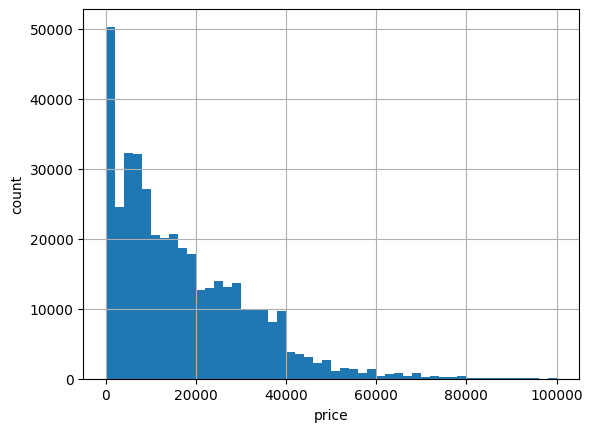

In [36]:
# Plot a histogram of the 'price' column for all rows where 
# the price is less than $100k. Use 50 bins.

#df['price']
# So only keeping the rows where the price of the car is under 100k and then plot a histogram with 50 bins ?
price_under_100 = df[df['price'] < 100000]['price']
price_under_100.hist(bins=50)
plt.xlabel('price')
plt.ylabel('count')

In [37]:
# Print all dataframe rows where the price is above 1 million.

df[df.price >= 1000000]

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
377396,7304058775,https://killeen.craigslist.org/ctd/d/belton-th...,killeen / temple / ft hood,https://killeen.craigslist.org,1234567,1955.0,chevrolet,NaN,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00X0X_1HYYivCJqB...,THE 38TH ANNUAL NATIONALLY ADVERTISED BELTON S...,NaN,tx,31.052169,-97.497654,2021-04-09T06:01:57-0500
232829,7313752706,https://charlotte.craigslist.org/cto/d/charlot...,charlotte,https://charlotte.craigslist.org,1000000,2016.0,ford,f150,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00M0M_ibJSZXey7A...,I pay cash on the spot for any running car tru...,NaN,nc,35.190800,-80.744800,2021-04-28T08:26:48-0400
327938,7314563134,https://altoona.craigslist.org/cto/d/revloc-bu...,altoona-johnstown,https://altoona.craigslist.org,3226714,2002.0,NaN,any and all,fair,8 cylinders,...,mid-size,sedan,blue,https://images.craigslist.org/00B0B_heEI8cTCHX...,Buying Junk/Unwanted/Crashed Vehicles Cars-tru...,NaN,pa,40.480100,-78.726300,2021-04-29T18:24:17-0400
280,7315849335,https://bham.craigslist.org/cto/d/trussville-1...,birmingham,https://bham.craigslist.org,987654321,1960.0,chevrolet,NaN,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00E0E_fZYzwRGkoI...,(TRADE VALUE IS HIGHER )I have a 1960 Impala h...,NaN,al,33.633900,-86.598100,2021-05-02T13:24:09-0500
233201,7312388595,https://charlotte.craigslist.org/cto/d/charlot...,charlotte,https://charlotte.craigslist.org,1000000,2016.0,ford,f150,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00M0M_ibJSZXey7A...,I pay cash on the spot for any running car tru...,NaN,nc,35.190800,-80.744800,2021-04-25T13:05:30-0400
377515,7301832876,https://killeen.craigslist.org/ctd/d/belton-th...,killeen / temple / ft hood,https://killeen.craigslist.org,1234567,1955.0,chevrolet,NaN,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00X0X_1HYYivCJqB...,THE 38TH ANNUAL NATIONALLY ADVERTISED BELTON S...,NaN,tx,31.052169,-97.497654,2021-04-04T17:28:43-0500
153082,7305153975,https://indianapolis.craigslist.org/cto/d/indi...,indianapolis,https://indianapolis.craigslist.org,1234567890,2006.0,volvo,vnl,fair,NaN,...,NaN,NaN,black,https://images.craigslist.org/01212_h8lmJc10P0...,2006 Volvo VNL Twin-screw/sleeper motor has un...,NaN,in,39.785100,-86.159500,2021-04-11T11:19:14-0400
283906,7314839271,https://nh.craigslist.org/cto/d/tyngsboro-mill...,new hampshire,https://nh.craigslist.org,5000000,2021.0,NaN,all,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00K0K_6qH8KCkbyV...,WE NEED INVENTORY! We have opened the Vault a...,NaN,nh,42.672400,-71.415800,2021-04-30T11:57:41-0400
318592,7308056031,https://eugene.craigslist.org/cto/d/florence-2...,eugene,https://eugene.craigslist.org,3736928711,2007.0,toyota,tundra,excellent,8 cylinders,...,full-size,pickup,silver,https://images.craigslist.org/00v0v_3K0RsmdR5c...,Selling my 2007 Toyota Tundra SR5 four wheel d...,NaN,or,44.066092,-124.037561,2021-04-16T18:16:12-0700
288356,7302369138,https://akroncanton.craigslist.org/cto/d/barbe...,akron / canton,https://akroncanton.craigslist.org,123456789,1965.0,chevrolet,project,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00Q0Q_i7qdTN6X31...,"1965 Chevy Nova $10,000 FIRM. New floors, new ...",NaN,oh,41.019700,-81.621200,2021-04-05T19:34:36-0400


**Question:** What does your intuition say about these car listings? Are these mostly nonsense prices?

**Answer:** `Given that from the count we saw that we have around 400k non null values and from the histogram we have about alot of cars listed at 0 and 57 cars over a million, since this is craigslist the price is most likely in USD and the majority of them are probably used and old so it would make sense for most of them to fall under the 0-20k price range. Given that and that craigslist is an open marketplace for listings its likely that alot of the prices are nonsense or exaggerated. I would be more inclined to trust the prices in the 0-20k range excluding the ones that are actually 0 more than those above that range although we could loosen it a bit up to about 40k`

In [38]:
# Use the pandas.DataFrame.value_counts method to print a count
# of unique values in the 'condition' column in descending order.

df['condition'].value_counts()

condition
good         115385
excellent     96425
like new      20150
fair           6441
new            1241
salvage         572
Name: count, dtype: int64

<Axes: xlabel='condition'>

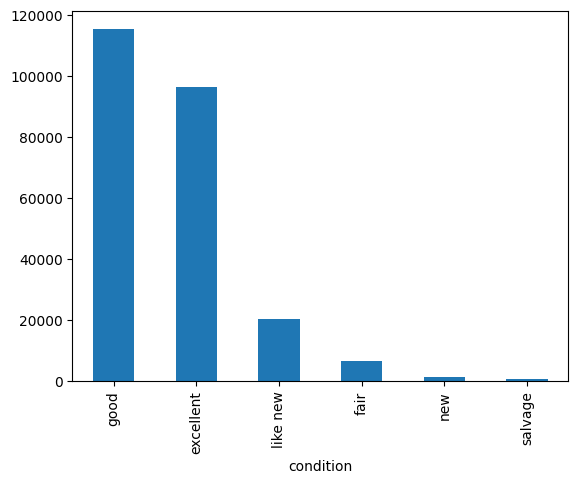

In [39]:
# Plot a histogram of the 'condition' values to see the same
# information more visually.

#df['condition'].hist()

df['condition'].value_counts().plot(kind='bar')

In [40]:
# Again use the value_counts method, this time to print a count
# of unique values for 'title_status'.

df.title_status.value_counts()

title_status
clean         384924
rebuilt         6828
salvage         3662
lien            1356
missing          763
parts only       188
Name: count, dtype: int64

<Axes: xlabel='title_status'>

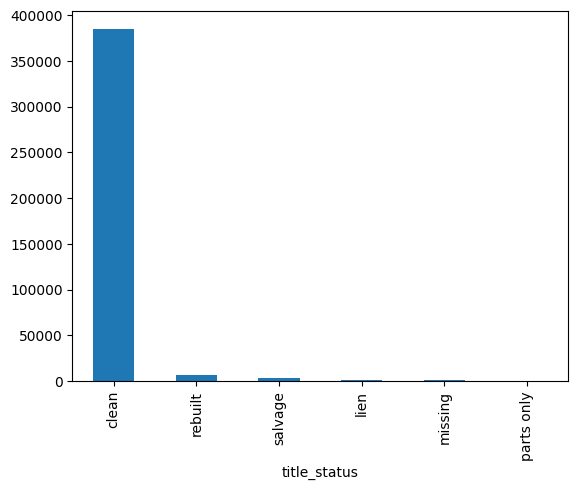

In [41]:
# And plot a histogram of the 'title_status' values.

#df['title_status'].hist()

df['title_status'].value_counts().plot(kind='bar')

## Removing garbage

We can already start removing some of the data. This step could also be done after splitting the data into the test- and training sets.

In [42]:
# Again, to avoid mistakes, we create a copy of the data to work on
reduced_df = df.copy() # had to change vehicles to df, we did not name it vehicles

# Remove all rows where price is zero or less
reduced_df = reduced_df[reduced_df['price'] > 0]

# Remove all rows where price is not set
reduced_df = reduced_df[reduced_df['price'].notna()]

# Remove all rows where price is above $1000,000
reduced_df = reduced_df[reduced_df['price'] < 1000000]

# Remove all rows where neither model nor manufacturer is defined
reduced_df = reduced_df[~((reduced_df.manufacturer.isnull()) & (reduced_df.manufacturer.isnull()))]

# Remove 'VIN', county, id, region_url and image_url columns
reduced_df = reduced_df.drop(columns=[
    'county', 
    'id', 
    'region_url', 
    'url', 
    'image_url',
    'VIN'
])

# Print the first 5 rows of the dataframe
reduced_df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,description,state,lat,long,posting_date
196639,detroit metro,2800,2009.0,chrysler,sebring,like new,4 cylinders,gas,114824.0,clean,automatic,fwd,compact,sedan,blue,09 chrysler sebring sedan with 114824 miles on...,mi,42.331600,-83.128800,2021-05-03T12:00:07-0400
322322,portland,7995,2010.0,subaru,forester 2.5 x,good,4 cylinders,gas,74890.0,salvage,automatic,4wd,mid-size,wagon,blue,2010 SUBARU FORESTER WAGON PZEV MODEL RUNS AND...,or,45.291230,-122.949765,2021-05-04T10:50:59-0700
100078,jacksonville,1950,2007.0,toyota,camry le,good,4 cylinders,gas,102576.0,clean,automatic,fwd,mid-size,sedan,NaN,Will consider all offers. Cash only. 2007 Beig...,fl,30.262783,-81.557314,2021-04-18T16:22:02-0400
290458,cincinnati,13500,2020.0,chevrolet,spark 4dr hb cvt ls,NaN,NaN,NaN,17282.0,clean,automatic,fwd,NaN,NaN,custom,***Call Us for more information at: 513-453-41...,oh,39.171991,-84.271999,2021-04-23T17:45:29-0400
90570,"washington, DC",38990,2020.0,jaguar,f-pace 25t sport utility,good,NaN,gas,10028.0,clean,other,NaN,NaN,other,black,Carvana is the safer way to buy a car During t...,dc,38.890000,-77.030000,2021-04-28T07:22:13-0400


### Creating a test set

Before we go any further, we need to set aside a test set. Since we have quite a lot of data we won't worry about stratified sampling (although we will keep it in mind in later exercises if we run into issues when we test our models with the test set). Since we will be loading the same dataset again in future exercises, we use a seed so that we can reproduce the same train/test split again without needing to save the data.

In [43]:
# Use the sklearn.train_test_split method to split the data (reduced_df) into a test and train set.
# Set aside 10% of the data for the test set and use a random seed of 123
# Name the train set dataframe variable `train_set`. This is the dataframe we
# will continue exploring.

from sklearn.model_selection import train_test_split

train_split = 0.1

train_set, test_set = train_test_split(reduced_df, test_size=train_split, random_state=123)

In [44]:
# Count non-null cells in all columns in the test set (df).

test_set.count()

region          35891
price           35891
year            35891
manufacturer    35891
model           35440
condition       21963
cylinders       21204
fuel            35700
odometer        35697
title_status    35223
transmission    35741
drive           24982
size            10063
type            28095
paint_color     25096
description     35890
state           35891
lat             35594
long            35594
posting_date    35891
dtype: int64

In [45]:
# Use the 'info' method to print a summary of the training data

train_set.info()

<class 'pandas.DataFrame'>
Index: 323010 entries, 178671 to 299209
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        323010 non-null  str    
 1   price         323010 non-null  int64  
 2   year          323006 non-null  float64
 3   manufacturer  323010 non-null  str    
 4   model         319077 non-null  str    
 5   condition     198643 non-null  str    
 6   cylinders     191864 non-null  str    
 7   fuel          321120 non-null  str    
 8   odometer      321140 non-null  float64
 9   title_status  316774 non-null  str    
 10  transmission  321534 non-null  str    
 11  drive         225659 non-null  str    
 12  size          90666 non-null   str    
 13  type          254523 non-null  str    
 14  paint_color   227335 non-null  str    
 15  description   323009 non-null  str    
 16  state         323010 non-null  str    
 17  lat           320115 non-null  float64
 18  long          3

## Exploring relationships

Now we can start looking into how the price is affected by the other attributes.

In [46]:
# It would be preferable to think in terms of the age of the car, rather than the
# year it was manufactured. Should we define the age as the number of years between now
# and the manufactury year? First, lets check the highest value for year in the dataframe

print(
    'Highest year in the data: ',
    train_set['year'].max()
)

Highest year in the data:  2022.0


In [53]:
# So the newest cars are from 2022, but the data is crawled in 2021. Weird.
# How many rows have the year 2022?

(train_set['year'] == 2022).sum()

62

In [54]:
# So lets define the age as the difference between the 'year' column and the highest value in the 
# 'year' column. Create a new column with this value and call it 'age'

train_set['age'] = train_set['year'].max() - train_set['year']
train_set['age']

178671     8.0
115417     5.0
183330     8.0
67156      8.0
357797    13.0
          ... 
30575     70.0
315268     4.0
289859    30.0
199620    10.0
299209     5.0
Name: age, Length: 323010, dtype: float64

In [55]:
# Check how strongly each of the numerical attribute columns correlate 
# with the price. Print the correlation values in descending order.

correlation = train_set.corr(numeric_only=True)
print("full matrix")
print(correlation)
print("only price desc")
correlation['price'].sort_values(ascending=False)

full matrix
             price      year  odometer       lat      long       age
price     1.000000  0.342421 -0.179397 -0.005718 -0.079239 -0.342421
year      0.342421  1.000000 -0.176947 -0.016745  0.005907 -1.000000
odometer -0.179397 -0.176947  1.000000  0.001932  0.007455  0.176947
lat      -0.005718 -0.016745  0.001932  1.000000 -0.134000  0.016745
long     -0.079239  0.005907  0.007455 -0.134000  1.000000 -0.005907
age      -0.342421 -1.000000  0.176947  0.016745 -0.005907  1.000000
only price desc


price       1.000000
year        0.342421
lat        -0.005718
long       -0.079239
odometer   -0.179397
age        -0.342421
Name: price, dtype: float64

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='odometer', ylabel='price'>,
        <Axes: xlabel='age', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='odometer'>,
        <Axes: xlabel='odometer', ylabel='odometer'>,
        <Axes: xlabel='age', ylabel='odometer'>],
       [<Axes: xlabel='price', ylabel='age'>,
        <Axes: xlabel='odometer', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>]], dtype=object)

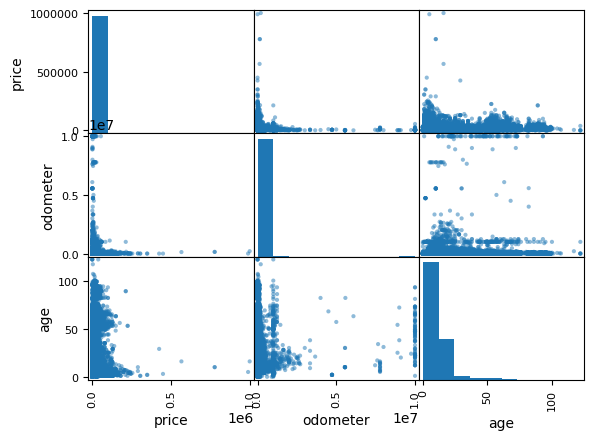

In [56]:
# Use the pandas.plotting scatter_matrix function
# to create scatter plot of price, odometer and age
from pandas.plotting import scatter_matrix

scatter_matrix(train_set[['price','odometer', 'age']])

**Question:** Do you have any observations about the age/price distribution? Does it look like there are outliers in the odometer column?

**Answer:** `Yes we have some extreme outliers in age/odometer with 1e7 also with price around 1e6.`

<Axes: xlabel='age', ylabel='odometer'>

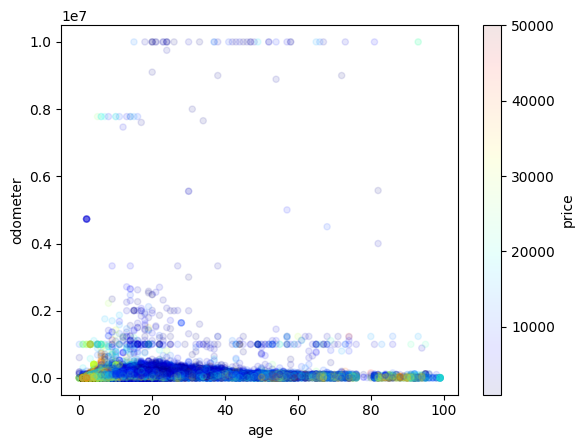

In [51]:
# Create a scatter plot of the data with 'age' on the horizontal axis and 'odometer'
# on the vertical axis. Only use data where the price is between $1000 and $50,000, 
# where the odometer value is less than 1000,000 and the age is less than 100 years.
# Assign the points on the scatter plot a color according to the price.

# (Hint: For better visibility, an alpha value of 0.1 and the colormap 
# plt.get_cmap('jet') are recommended)

filtered_train_set = train_set[(train_set['price'] >= 1000) & (train_set['price'] <= 50000) & (train_set['odometer'] < 10000000) & (train_set['age'] < 100)]
filtered_train_set.plot(kind='scatter', x='age', y='odometer', alpha=0.1, c='price', cmap=plt.get_cmap('jet'))

**Question:** Looking at this plot, how is price affected by mileage and age?

**Answer:** The age affects the price like you would assume, the older the car is the less expensive it tends to be. Although when the car start getting to around 70+, the price seems to rise since these cars are more vintage and sought after. The mileage on the other hand seems to only negatively affect the price, as the price gets lower the higher the odometer is.

**Question:** Do you see an age group which has very few cars for sale? Do you have a hypothesis as to why this might be? 

**Answer:** There seems to be a gap around the 80 year mark. This should be around the late 1930's to mid 1940's. WWII was happening at this time so car production essentially halted during this time

Next up: Color. Is there a difference in the average price for cars painted in different colors? Can we maybe remove the `paint_color` column altogether?

In [62]:
# What is the mean price, year and odometer for each paint color type?

# (Hint: To print the mean of the numerical columns with the data split based on paint color,
# use the pandas.DataFrame.groupby method to split the data into groups based on the 
# 'paint_color' attribute and the 'mean' aggregator to calculate the group mean.)

print(train_set.groupby('paint_color')[['price', 'year', 'odometer']].mean())

                    price         year       odometer
paint_color                                          
black        21846.129015  2012.954025   84353.776290
blue         17186.821080  2010.691544   97249.921797
brown        16257.805010  2008.837765  108463.902218
custom       15964.700606  2008.557721  112922.436116
green        12977.924847  2003.952895  130242.796821
grey         15572.054208  2011.492432  105821.101383
orange       19568.716826  2008.288646   78684.748968
purple       14834.656134  2004.767658  104847.811321
red          19476.149774  2010.256155   88622.072386
silver       16820.279051  2011.857730   97341.107294
white        22344.315748  2012.752384   91323.590740
yellow       19687.582822  2002.733470   89592.373717


In [63]:
# Do the same as above, but with the median instead of the mean.

print(train_set.groupby('paint_color')[['price', 'year', 'odometer']].median())

               price    year  odometer
paint_color                           
black        18990.0  2014.0   73231.0
blue         13900.0  2013.0   88183.5
brown        12274.5  2012.0  102000.0
custom       12400.0  2012.0   95492.0
green         8500.0  2006.0  118000.0
grey         11699.0  2013.0   99866.0
orange       18590.0  2014.0   64029.5
purple        9995.0  2010.0  100581.0
red          16590.0  2013.0   75571.0
silver       13500.0  2013.0   92258.0
white        19968.0  2014.0   80701.0
yellow       15900.0  2008.0   75981.0


In [64]:
# How many rows are there of each paint color?

print(train_set['paint_color'].value_counts())

paint_color
white     59253
black     48723
silver    33338
blue      24279
red       23275
grey      18964
green      5562
custom     5284
brown      5190
yellow     1467
orange     1462
purple      538
Name: count, dtype: int64


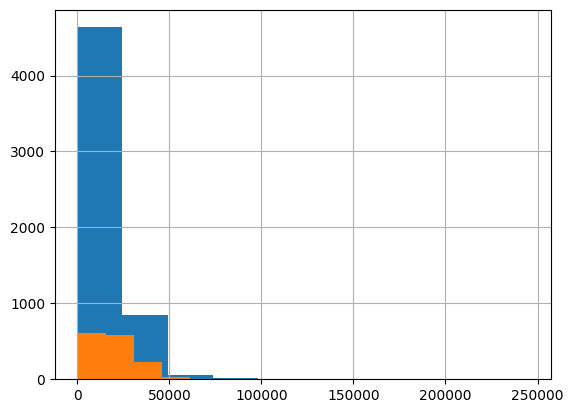

In [70]:
# Green cars seem to be on average cheaper and orange cars on average more expensive.
# Try plotting a histogram of the prices for these two colors.

green_cars = train_set[train_set['paint_color'] == 'green']
orange_cars = train_set[train_set['paint_color'] == 'orange']

green_cars['price'].hist()
orange_cars['price'].hist()

plt.show()


**Question:** Looking at the data and using your intuition, do you think color is a good attribute for modeling? Why or why not?

**Answer:** Color is probably not a good attribute for modeling. The number of cars per color varies hugely, so some averages can be unreliable. Also the price difference between colors is likely down to other factors, like age and mileage.

In [71]:
# There is an attribute called 'posting_date' which is the timestamp of when the 
# car listing was posted. Here is an example:

print(df.iloc[0].posting_date)

# Next, lets look at how this attribute affects the price. First, we create a 
# copy of the data, since we will be creating new columns.

date_df = df.copy()

2021-05-03T12:00:07-0400


In [72]:
# Create a new column in the date_df dataframe with the posting_date attribute as an object
# of the type datetime using the pandas.to_datetime module. Use the column header 'posting_datetime'.
# Use UTC time (set argument utc=True) and remove timezone information with '.dt.tz_convert(None)'

date_df['posting_datetime'] = pd.to_datetime(date_df['posting_date'], utc=True).dt.tz_convert(None)

In [78]:
# Create a column titled 'day_of_month' with the month day of the posting_date
# (Hint: pandas.Series.dt.day)

date_df['day_of_month'] = date_df['posting_datetime'].dt.day

In [79]:
# Create a column titled 'day_of_week' with the weekday of the posting_date

date_df['day_of_week'] = date_df['posting_datetime'].dt.weekday

In [80]:
# Create a column titled 'hour' with the hour of day of the posting_date

date_df['hour'] = date_df['posting_datetime'].dt.hour

In [82]:
# Create a column titled 'days_since' with the number of days since the listing was posted

# (Hint: Use the datetime python module's datetime.now() method to get the datetime now)

import datetime

date_df['days_since'] = datetime.datetime.now() - date_df['posting_datetime']

Lets have a look the distribution of our new variables:

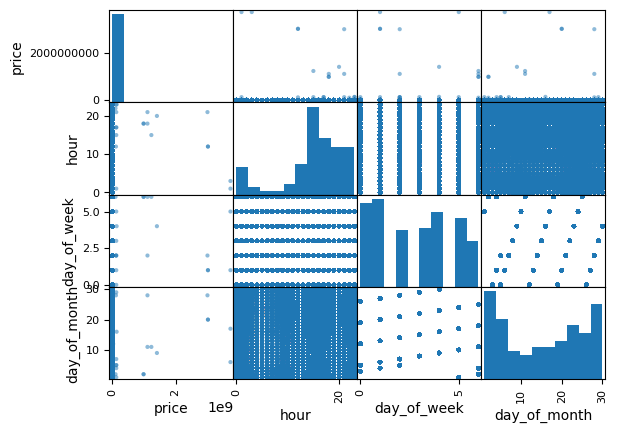

In [83]:
pd.plotting.scatter_matrix(date_df[['price','hour','day_of_week','day_of_month','days_since']]);

**Question:** Do you think `posting_time` is a good attribute for predicting the price? Why/why not?

**Answer:** Posting time is not a good attribute for predicting price. The scatter matrix shows no clear relationship between price and any of the time variables. Intuitively this also makes sense, as the time a listing is posted should have no effect on the value of the car.

Now lets look at the data in the latitude and longitude columns.

<Axes: xlabel='long', ylabel='lat'>

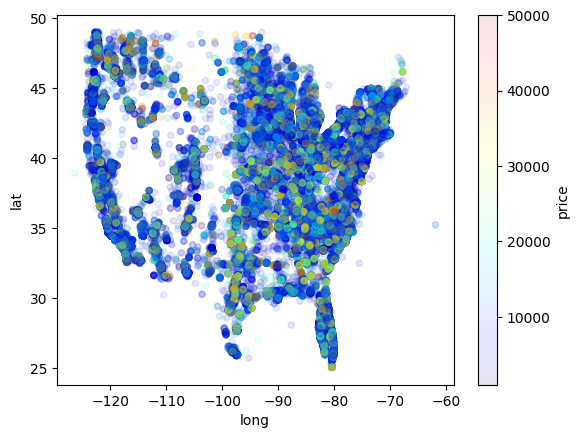

In [85]:
# Plot the listed cars on geographical scatterplot with the color of the dots
# representing the car price. Use the alpha parameter to improve the visualization.
# Only plot cars with prices ranging from $1000 to $50000
# Only plot the continental United States (approximately 25<lat<50, -130<long<-60)


filtered_df = train_set[(train_set['price'] >= 1000) & (train_set['price'] <= 50000) & (train_set['lat'] > 25) & (train_set['lat'] < 50) & (train_set['long'] > -130) & (train_set['long'] < -60)]
filtered_df.plot(kind='scatter', x='long', y='lat', alpha=0.1, c='price', cmap=plt.get_cmap('jet'))

**Question:** Can you spot any obvious geographical pattern in the price distribution? You can try zooming into a particular region.

**Answer:** There is a slight pattern in the coastal areas, particularly the west coast and northeast. They seem to have slightly higher prices compared to the middle of the country. This could reflect the higher cost of living in these areas. This makes sense since cars in California or New York would be priced differently than in somewhere like Kansas.

**Question:** Do you think `lat` and/or `long` are good attributes for predicting the price?

**Answer:** Lat and long could be useful attributes for predicting price since they indicate the location of the car in the country, and there seems to be a slight regional pattern with coastal areas tending to have higher prices

In [86]:
# Another attribute we can assume affects the price of the car is the condition it is in.
# Print a list of all the values the 'condition' column takes.

print(train_set['condition'].unique())

<StringArray>
[nan, 'excellent', 'new', 'good', 'like new', 'fair', 'salvage']
Length: 7, dtype: str


In [87]:
# How many rows are there of each condition?

print(train_set['condition'].value_counts())

condition
good         97491
excellent    78151
like new     16443
fair          5225
new            848
salvage        485
Name: count, dtype: int64


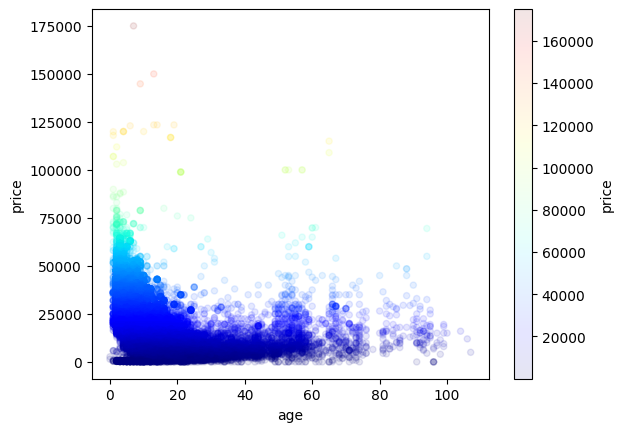

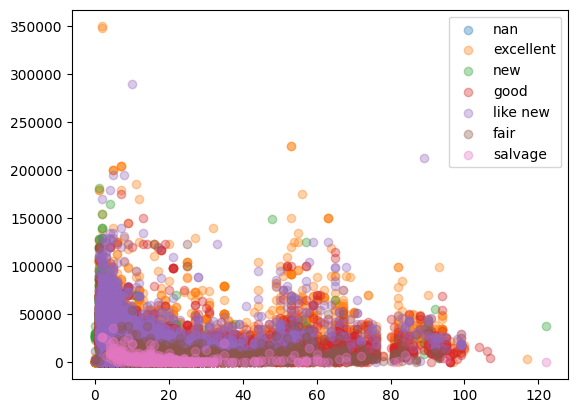

In [99]:
# Create a scatter plot of the data where 'condition' is 'good' with 'age' on the 
# horizontal axis and 'price' on the vertical axis.

filtered_cond = train_set[(train_set['condition'] == 'good')]
filtered_cond.plot(kind='scatter', x='age', y='price', alpha=0.1, c='price', cmap=plt.get_cmap('jet'))

# Create another figure for the other values of 'condition'. 
# Make the points which correspond to cars in different conditions a different color.
# Plot these all in one figure and use transparancy (alpha) to improve visibility.

fig, ax = plt.subplots()
for condition in train_set['condition'].unique():
    filtered = train_set[train_set['condition'] == condition]
    ax.scatter(filtered['age'], filtered['price'], alpha=0.35, label=condition)
plt.legend()
plt.show()


**Question:** Do you think `condition` is a good attribute for predicting the price?

**Answer:** Condition is likely a useful attribute for predicting price, but it is not the strongest predictor. Something like age would probably have a stronger effect. But if you have two otherwise identical cars, better condition should result in a higher price.

In [100]:
# How many rows are there of each manufacturer?

print(train_set['manufacturer'].value_counts())

manufacturer
ford               55430
chevrolet          43375
toyota             27038
honda              17001
jeep               14941
nissan             14874
ram                14037
gmc                13178
bmw                11748
dodge              10571
mercedes-benz       8924
hyundai             8031
subaru              7749
volkswagen          7586
lexus               6605
kia                 6457
audi                6129
cadillac            5610
chrysler            4832
acura               4831
buick               4435
mazda               4332
infiniti            3809
lincoln             3451
volvo               2800
mitsubishi          2664
mini                1932
pontiac             1909
rover               1713
jaguar              1619
porsche             1125
mercury              963
saturn               902
tesla                749
alfa-romeo           748
fiat                 638
harley-davidson      125
ferrari               67
datsun                55
aston-martin

In [102]:
# How many rows are there of each fuel type?

print(train_set['fuel'].value_counts())

fuel
gas         273119
other        23041
diesel       19560
hybrid        4091
electric      1309
Name: count, dtype: int64


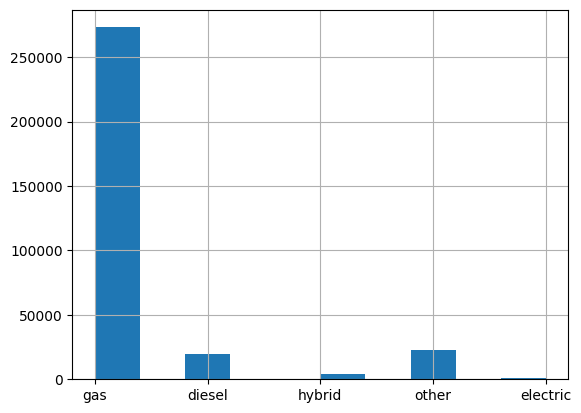

In [103]:
# Plot a histogram of the 'fuel' values.


train_set['fuel'].hist()

plt.show()

In [104]:
# How many rows are there of each size?

print(train_set['size'].value_counts())

size
full-size      47694
mid-size       26298
compact        14390
sub-compact     2284
Name: count, dtype: int64


In [105]:
# How many rows are there of each value of the 'cylinders' column?

print(train_set['cylinders'].value_counts())

cylinders
6 cylinders     73213
4 cylinders     60106
8 cylinders     54818
5 cylinders      1315
10 cylinders     1142
other             734
3 cylinders       440
12 cylinders       96
Name: count, dtype: int64


In [107]:
# Print the number of unique 'model' values present in the data


print(train_set['model'].nunique())

20965


In [109]:
# Wow, that is a lot of unique model names!

# How many rows are there of each 'model' value where the 'manufacturer' is 'toyota'?
# Print the number of rows for the top 50 toyota 'model' names.

print(train_set[train_set['manufacturer'] == 'toyota']['model'].value_counts().head(50))

model
camry                        2448
tacoma                       2021
corolla                      1694
rav4                         1304
prius                        1155
tundra                       1109
sienna                        892
highlander                    833
4runner                       824
camry le                      461
tacoma access cab pickup      400
4runner sr5 sport utility     342
avalon                        335
corolla le                    325
tundra double cab sr          266
tundra crewmax sr5 pickup     253
sienna le                     239
tacoma double cab pickup      219
fj cruiser                    217
tacoma access cab sr5         213
camry se                      207
sequoia                       197
tacoma double cab             185
yaris                         185
4runner sr5                   179
land cruiser                  160
venza                         148
sienna xle                    147
camry le sedan 4d             144
camry xl

## Do your own exploring

Can you think of other aspects of the dataset you would like to explore? Are there distributions or relationships in the data which could be used when modeling?

In [ ]:
<TODO>